In [1]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader
from src.dataloading.gnndataloader import GNNDataLoader
from src.utils import get_data_env

In [2]:
epidata_nuts2 = GNNDataLoader('influenza', get_data_env(), nuts_level='nuts2', min_date='2006-05-15',max_date='2020-06-02', include_population=False, horizon_size = 1, horizon_leadtime = 3, sequence_length=12)
epidata_nuts2.add_time_features()
epidata_nuts2.set_splits()
epidata_nuts2.normalize()
epidata_nuts2.add_lagged_features(lags = 1)
epidata_nuts2.finalize()
epidata_nuts2_id  = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'identity_graph').construct_dataloaders()
epidata_nuts2_bn2  = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'boolean_neighbors_selfmn').construct_dataloaders()

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-01-30 (+15 weeks)
Dataloader temporal windowing: extending data collection from 2006-01-30 to 2005-10-17 (+15 weeks)
Dataloader temporal windowing: extending data collection from 2006-01-30 to 2005-10-17 (+15 weeks)


/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


⚠️  Input features are 3D (e.g., sequences). Only the last dimension will be used (flattened).

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 1])
➡️  Ground truth shape: torch.Size([38, 1])
✅ Snapshot ran successfully
Dataloader Snapshot: GraphDataLoaderEntry(x=(38, 3, 12), y=(38, 1), edge_index=(2, 210), edge_weight=(210,))
Epoch 1 train loss: 0.6814, val loss: 1.4368 ✓ (new best)
Test loss: 1.9894


/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


⚠️  Input features are 3D (e.g., sequences). Only the last dimension will be used (flattened).

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 1])
➡️  Ground truth shape: torch.Size([38, 1])
✅ Snapshot ran successfully
Dataloader Snapshot: GraphDataLoaderEntry(x=(38, 3, 12), y=(38, 1), edge_index=(2, 38), edge_weight=(38,))
Epoch 1 train loss: 0.6280, val loss: 1.3220 ✓ (new best)
Test loss: 1.9201


(<Figure size 1600x1000 with 2 Axes>,
 array([<Axes: title={'center': 'National aggregation of incidence'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 1'}, ylabel='incidence'>],
       dtype=object))

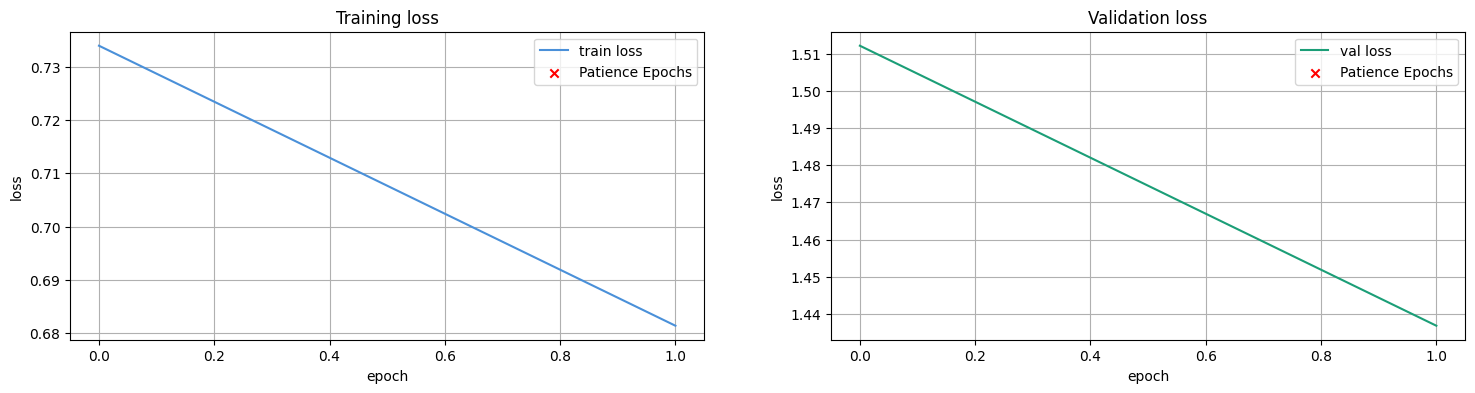

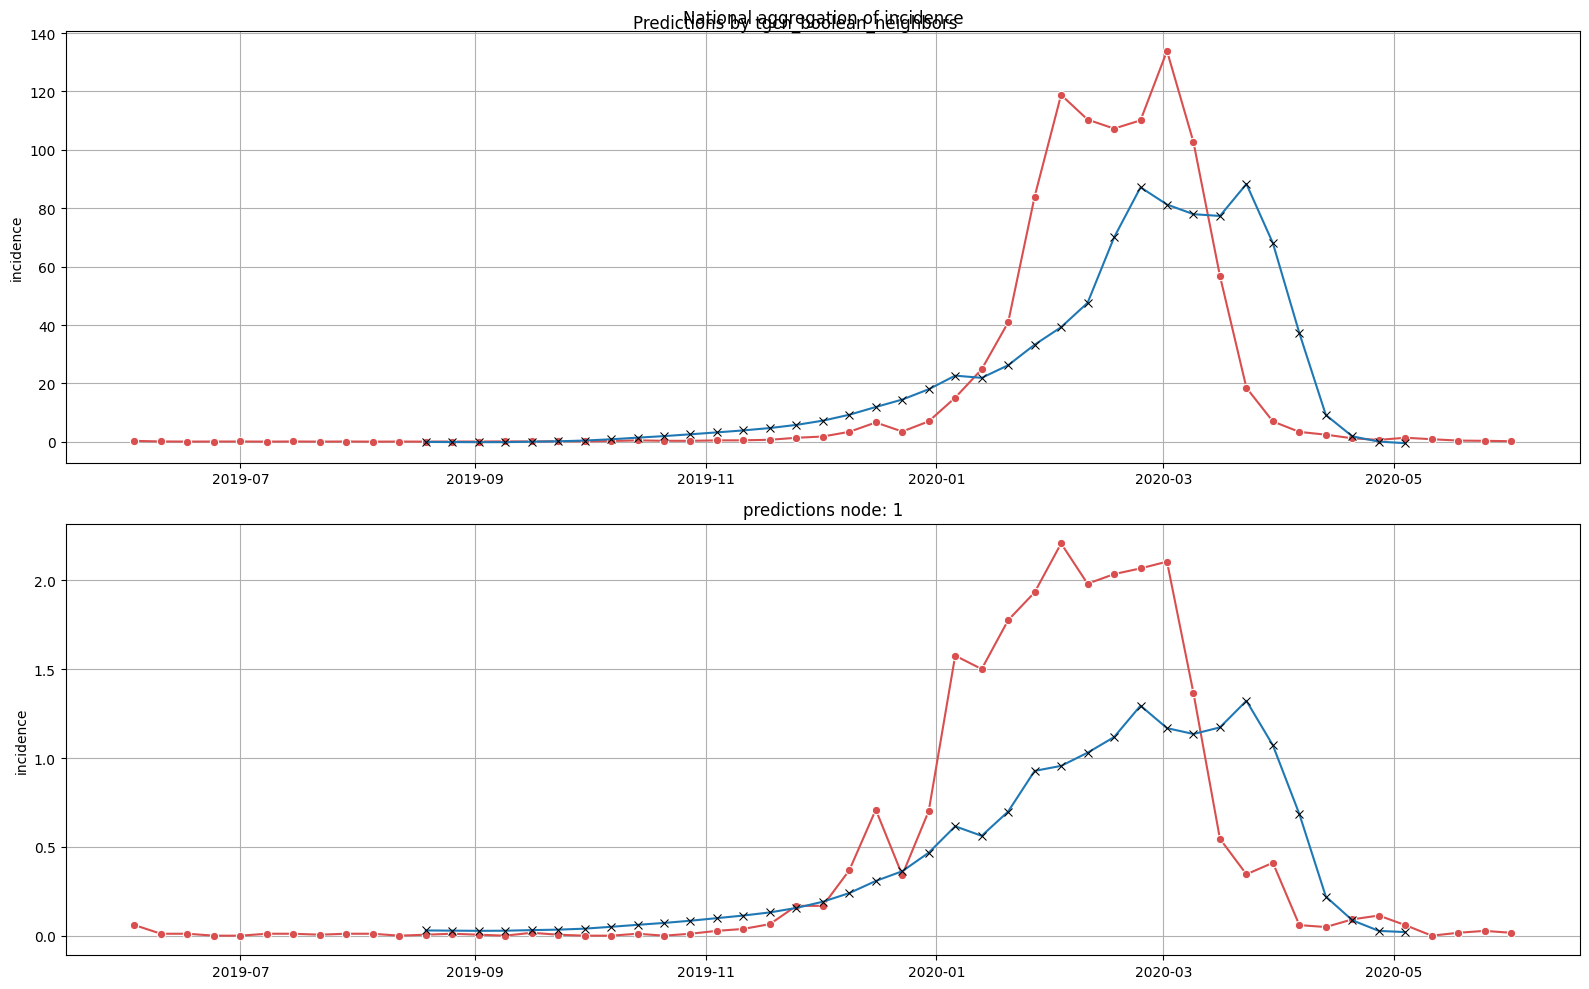

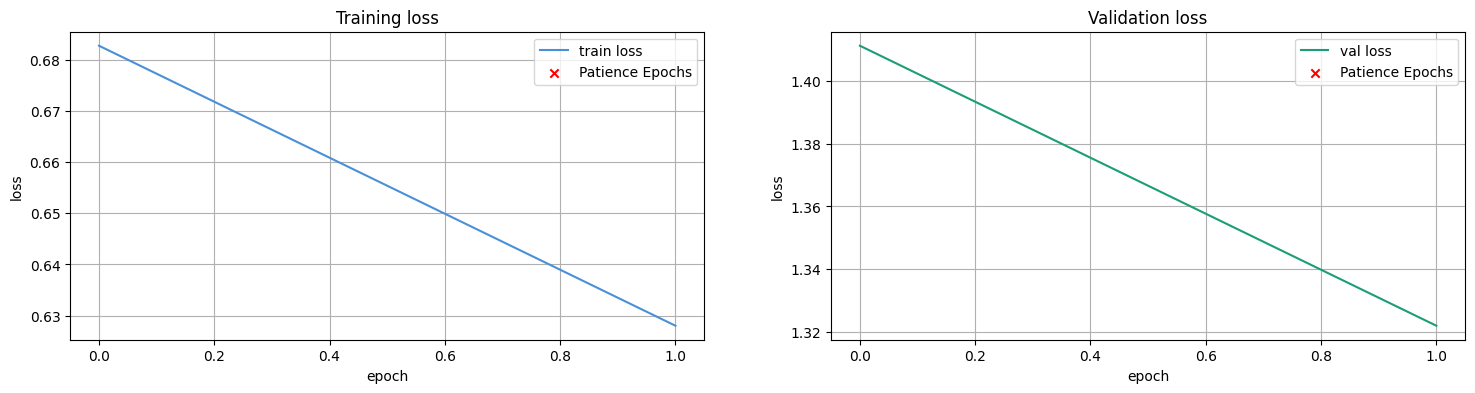

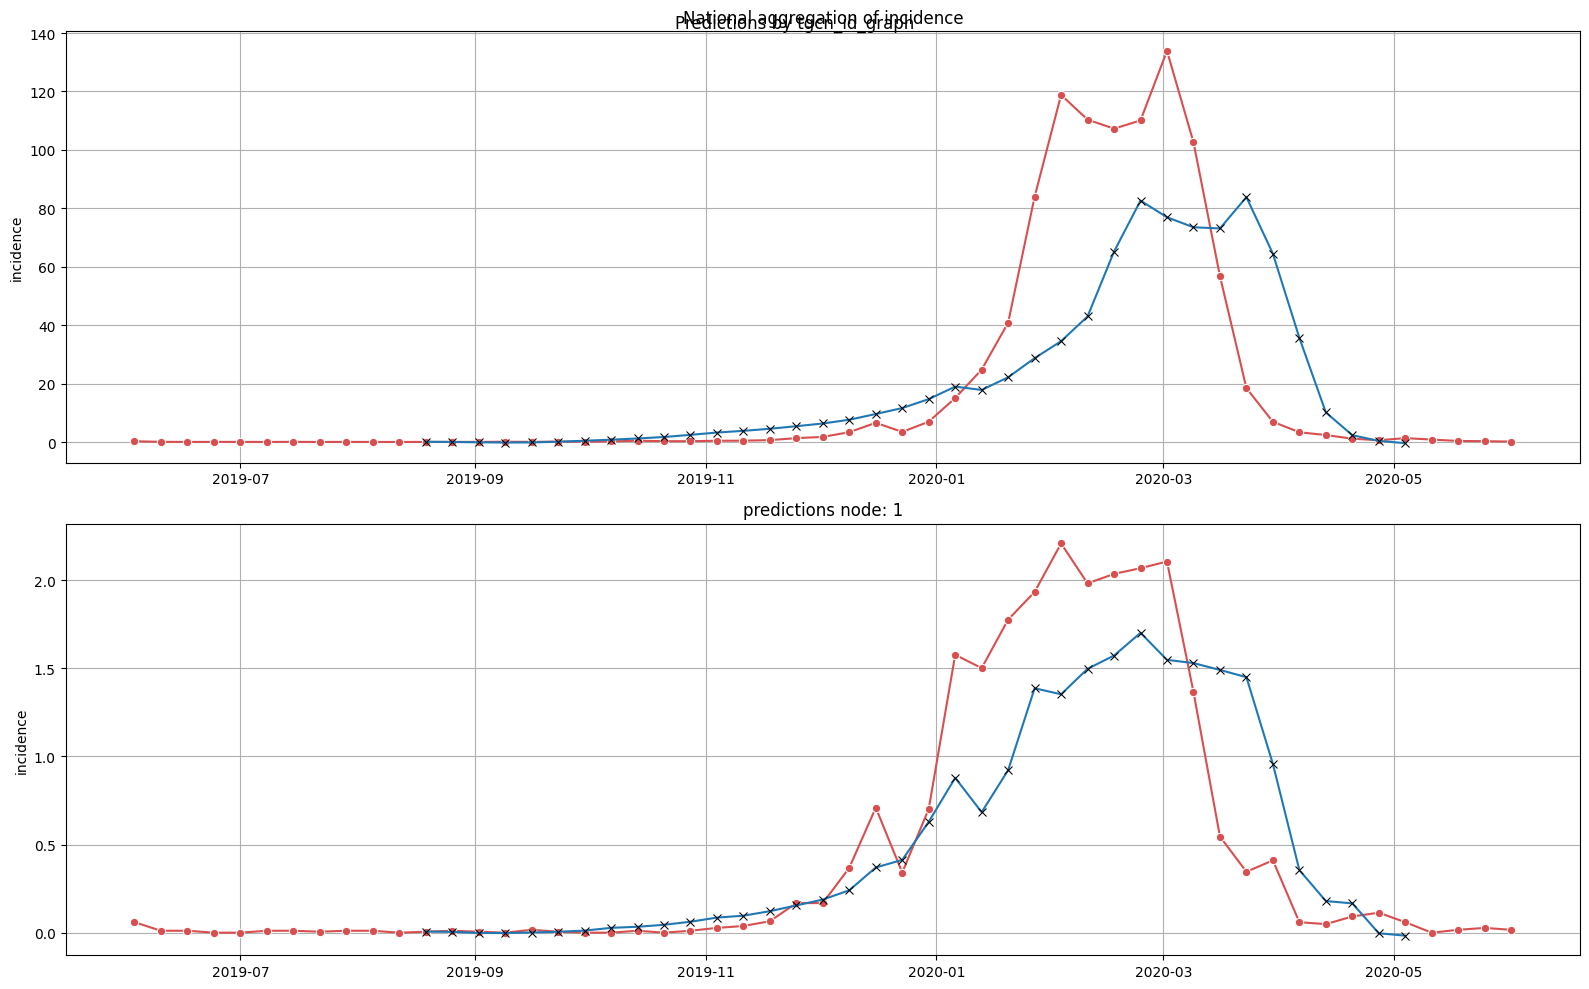

In [3]:
from src.models.spatialgcn_baseline import SpatialGCNModel

n_epochs = 2
lr       = 0.0001
min_delta= 0.001

ml2_bn = SpatialGCNModel(name = f'tgcn_boolean_neighbors', dataloader=epidata_nuts2_bn2)
ml2_bn.set_model_hparams()
ml2_bn.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler='plateau', min_delta = min_delta, loss = 'mse')
ml2_bn.run_snapshot(debug=True)
ml2_bn.train(verbose=2)
ml2_bn.forecast()
ml2_bn.show_forecasts(dataset='test',target_h = 0)


ml2_id = SpatialGCNModel(name = f'tgcn_id_graph', dataloader=epidata_nuts2_id)
ml2_id.set_model_hparams()
ml2_id.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler='plateau', min_delta = min_delta, loss = 'mse')
ml2_id.run_snapshot(debug=True)
ml2_id.train(verbose=2)
ml2_id.forecast()
ml2_id.show_forecasts(dataset='test',target_h = 0)



